<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/automata-celular_yosue_1/notebooks/prueba_diccionario_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#Importaciones:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [34]:
#Objetos de la matriz:

ESTADOS = {
    'BIOMASA': (0, 'green'),
    'FUEGO': (1, 'red'),
    'AGUA': (2, 'skyblue'),
    'CENIZA': (3, 'black'),
    'ROCA': (4, 'dimgray'),
    'HIERVA' : (5, 'gold')
}

colores = []

for datos in ESTADOS.values():
  datos_nuevos = datos[1]
  colores.append(datos_nuevos)

print(colores)

['green', 'red', 'skyblue', 'black', 'dimgray', 'gold']


In [35]:
#Tamaño de la matriz:
tmn=100
mapa= np.zeros((tmn,tmn),dtype=int)

mapa[int(tmn/2),int(tmn/2)] = ESTADOS['FUEGO'][0]


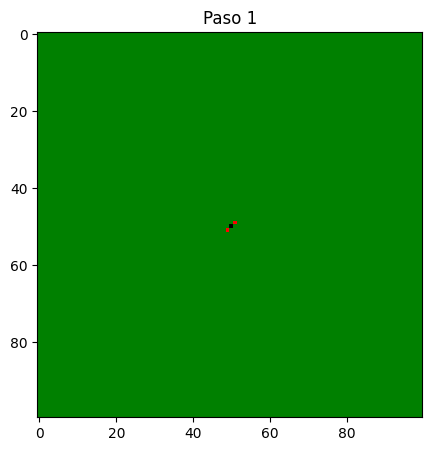

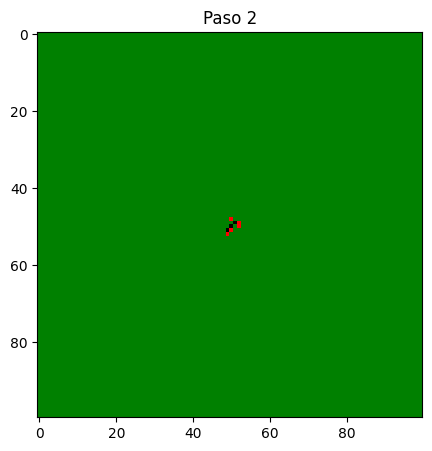

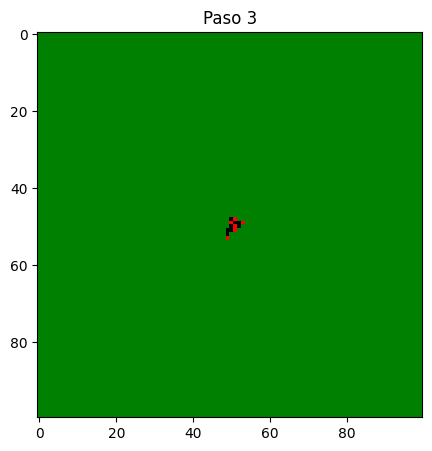

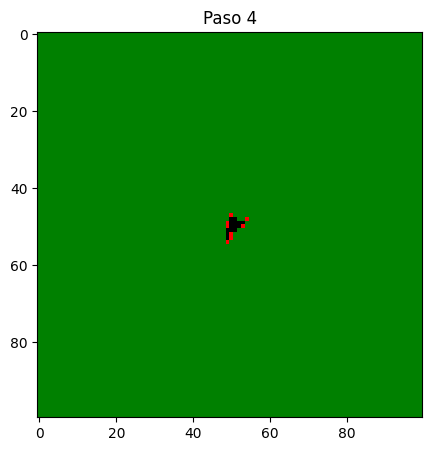

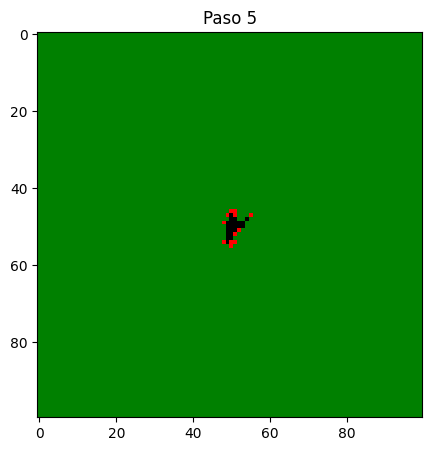

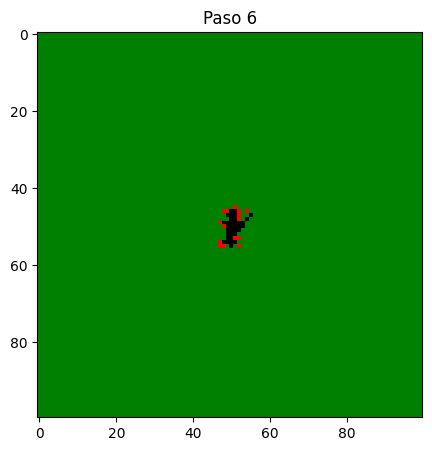

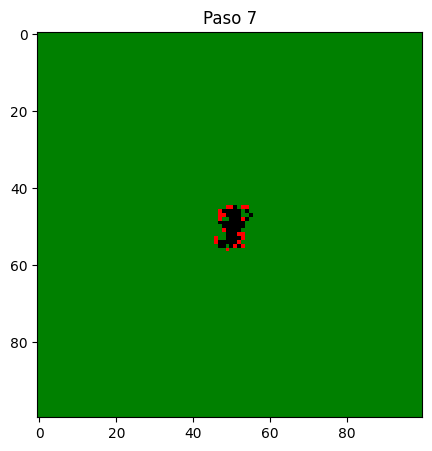

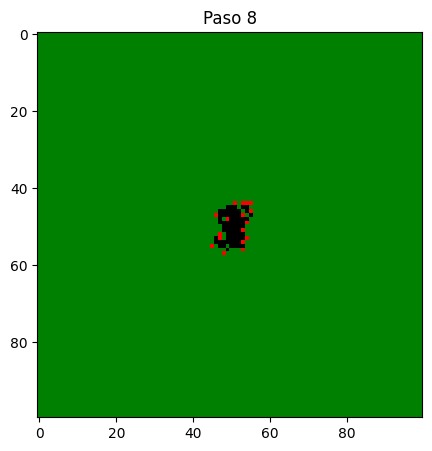

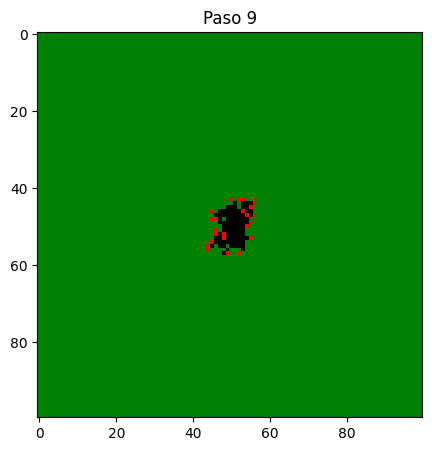

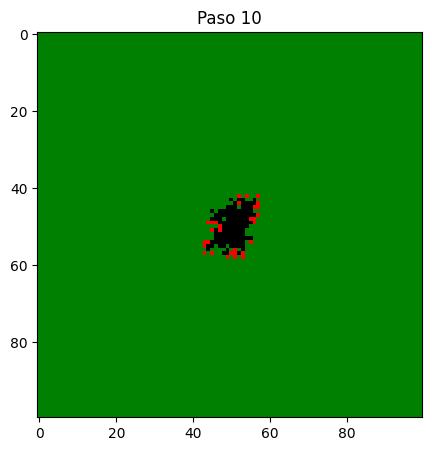

In [36]:
# Establecemos la propagación:
movimientos = [
    (-1, 0),  # Arriba
    (1, 0),   # Abajo
    (0, -1),  # Izquierda
    (0, 1),   # Derecha
    (-1, -1), # Diagonal Arriba-Izquierda
    (-1, 1),  # Diagonal Arriba-Derecha
    (1, -1),  # Diagonal Abajo-Izquierda
    (1, 1)    # Diagonal Abajo-Derecha
]


inflamable = [ESTADOS['BIOMASA'][0], ESTADOS['HIERVA'][0]]
pasos_totales = 10
pro_ignicion = 0.3

for paso in range(pasos_totales):
    futuro = mapa.copy()
    for f in range(tmn):
        for c in range(tmn):
            if mapa[f, c] == ESTADOS['FUEGO'][0]:
                # El fuego se convierte en ceniza en el siguiente turno
                futuro[f, c] = ESTADOS['CENIZA'][0]

                # Evaluar propagación a los vecinos
                for df, dc in movimientos:
                    nf = f + df  # nueva fila
                    nc = c + dc  # nueva columna

                    # Verificar que el vecino esté dentro de los límites de la matriz
                    if 0 <= nf < tmn and 0 <= nc < tmn:
                        if mapa[nf, nc] in inflamable:
                            if np.random.rand() < pro_ignicion:
                                futuro[nf, nc] = ESTADOS['FUEGO'][0]
    mapa = futuro

    paleta = ListedColormap(colores)
    plt.figure(figsize=(5,5))
    plt.imshow(mapa, cmap=paleta, vmin=0, vmax=len(colores)-1)
    plt.title(f'Paso {paso+1}')
    plt.show()

